<a href="https://colab.research.google.com/github/sa9855364-maker/AI-Facial-Surgery-Pipeline/blob/main/T1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print("1. Downloading CelebA Dataset (1.3 GB) - Please wait a few minutes...")
# هذا هو الرابط الحقيقي المباشر من سيرفرات جامعة برلين
!wget -c https://ftp.mi.fu-berlin.de/pub/cmb-data/celeba/img_align_celeba.zip -O celeba.zip

print("\n2. Unzipping the dataset...")
# فك الضغط
!unzip -q celeba.zip -d /content/celeba_faces

print("\n✅ تمت العملية الحقيقية بنجاح! مبروك أول Dataset على الكلاود.")

# لنقوم بعدد الصور لنثبت لكِ نجاح الأمر
images = os.listdir('/content/celeba_faces/img_align_celeba')
print(f"Number of downloaded faces: {len(images)} images!")


1. Downloading CelebA Dataset (1.3 GB) - Please wait a few minutes...
--2026-08-05 15:42:14--  https://ftp.mi.fu-berlin.de/pub/cmb-data/celeba/img_align_celeba.zip
Resolving ftp.mi.fu-berlin.de (ftp.mi.fu-berlin.de)... 160.45.117.8
Connecting to ftp.mi.fu-berlin.de (ftp.mi.fu-berlin.de)|160.45.117.8|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1443490838 (1.3G) [application/zip]
Saving to: ‘celeba.zip’

celeba.zip          100%[===================>]   1.34G  19.2MB/s    in 72s     

2026-08-05 15:43:26 (19.2 MB/s) - ‘celeba.zip’ saved [1443490838/1443490838]


2. Unzipping the dataset...

✅ تمت العملية الحقيقية بنجاح! مبروك أول Dataset على الكلاود.
Number of downloaded faces: 202599 images!


In [1]:
import os

print("1. Downloading CelebA Dataset (1.3 GB) - Please wait a few minutes...")
# هذا هو الرابط الحقيقي المباشر من سيرفرات جامعة برلين
!wget -c https://ftp.mi.fu-berlin.de/pub/cmb-data/celeba/img_align_celeba.zip -O celeba.zip

print("\n2. Unzipping the dataset...")
# فك الضغط
!unzip -q celeba.zip -d /content/celeba_faces

print("\n✅ تمت العملية الحقيقية بنجاح! مبروك أول Dataset على الكلاود.")

# لنقوم بعدد الصور لنثبت لكِ نجاح الأمر
images = os.listdir('/content/celeba_faces/img_align_celeba')
print(f"Number of downloaded faces: {len(images)} images!")

1. Downloading CelebA Dataset (1.3 GB) - Please wait a few minutes...
--2026-08-06 21:16:35--  https://ftp.mi.fu-berlin.de/pub/cmb-data/celeba/img_align_celeba.zip
Resolving ftp.mi.fu-berlin.de (ftp.mi.fu-berlin.de)... 160.45.117.8
Connecting to ftp.mi.fu-berlin.de (ftp.mi.fu-berlin.de)|160.45.117.8|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1443490838 (1.3G) [application/zip]
Saving to: ‘celeba.zip’

celeba.zip          100%[===================>]   1.34G  18.6MB/s    in 75s     

2026-08-06 21:17:51 (18.3 MB/s) - ‘celeba.zip’ saved [1443490838/1443490838]


2. Unzipping the dataset...

✅ تمت العملية الحقيقية بنجاح! مبروك أول Dataset على الكلاود.
Number of downloaded faces: 202599 images!


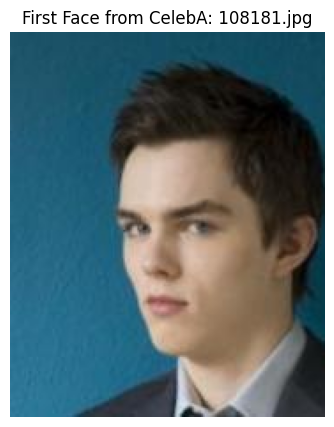

Image Size: (178, 218)


In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# المسار الذي توجد فيه الصور التي قمنا بفك ضغطها
folder_path = '/content/celeba_faces/img_align_celeba/'

# سنجلب اسم أول صورة فقط من الـ 200 ألف صورة
first_image_name = os.listdir(folder_path)[0]
full_image_path = os.path.join(folder_path, first_image_name)

# قراءة الصورة باستخدام مكتبة PIL
img = Image.open(full_image_path)

# عرض الصورة باستخدام مكتبة matplotlib
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
plt.title(f"First Face from CelebA: {first_image_name}")
plt.show()

# طباعة حجم الصورة (العرض والطول)
print(f"Image Size: {img.size}")

In [3]:
!pip install mediapipe==0.10.35

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.1 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


✅ تم اكتشاف وجه بنجاح باستخدام OpenCV!


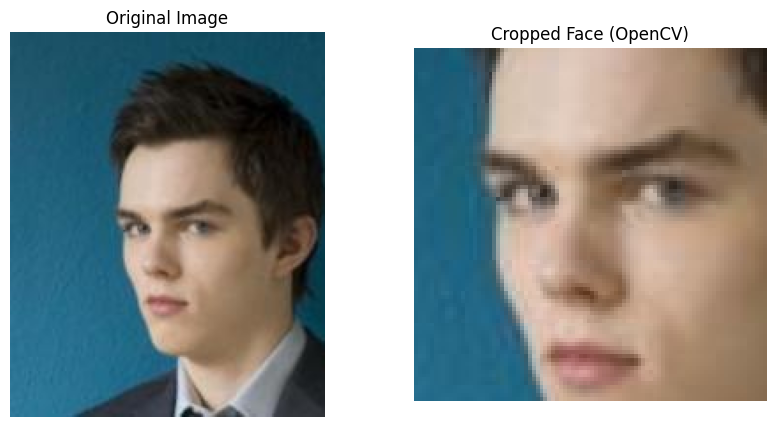

In [4]:
import cv2
import matplotlib.pyplot as plt
import os
import urllib.request

# 1. تحميل ملف الذكاء الاصطناعي الخاص بـ OpenCV لاكتشاف الوجوه
cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
cascade_path = "haarcascade_frontalface_default.xml"
if not os.path.exists(cascade_path):
    urllib.request.urlretrieve(cascade_url, cascade_path)

face_cascade = cv2.CascadeClassifier(cascade_path)

# 2. تحديد مسار الصورة
folder_path = '/content/celeba_faces/img_align_celeba/'
first_image_name = os.listdir(folder_path)[0]
full_image_path = os.path.join(folder_path, first_image_name)

# 3. قراءة الصورة
img = cv2.imread(full_image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# OpenCV يحتاج الصورة بالأبيض والأسود لاكتشاف الوجه أسرع
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 4. البحث عن الوجوه
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)

# 5. إذا وجد وجهاً، نقوم بقصه
if len(faces) > 0:
    print("✅ تم اكتشاف وجه بنجاح باستخدام OpenCV!")

    # الإحداثيات التي رجع بها الذكاء الاصطناعي
    x, y, w, h = faces[0]

    # قص الوجه
    cropped_face = img_rgb[y:y+h, x:x+w]

    # 6. عرض الصورة الأصلية بجوار المقصوصة
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(cropped_face)
    axes[1].set_title("Cropped Face (OpenCV)")
    axes[1].axis('off')

    plt.show()
else:
    print("❌ لم يتم العثور على وجه.")

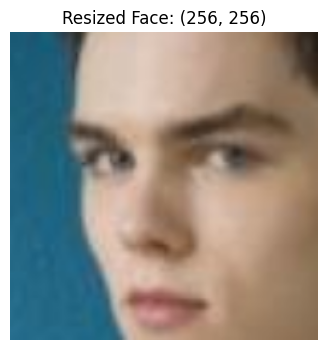

✅ تم توحيد حجم الوجه بنجاح وحفظه في: /content/clean_face_01.jpg


In [5]:
import cv2
import matplotlib.pyplot as plt

# تحديد المقاس الموحد الذي اتفق عليه فريقكم (غالباً 256 أو 512)
TARGET_SIZE = (256, 256)

# 1. تغيير حجم الوجه المقصوص (Resizing)
resized_face = cv2.resize(cropped_face, TARGET_SIZE)

# 2. عرض الوجه بعد تغيير حجمه
plt.figure(figsize=(4, 4))
plt.imshow(resized_face)
plt.title(f"Resized Face: {TARGET_SIZE}")
plt.axis('off')
plt.show()

# 3. حفظ الصورة النظيفة الجديدة (Save the processed image)
# سنقوم بحفظها بصيغة RGB الصحيحة
save_path = "/content/clean_face_01.jpg"
# OpenCV يفضل الألوان بصيغة BGR عند الحفظ، لذا نعكسها مرة أخرى
resized_face_bgr = cv2.cvtColor(resized_face, cv2.COLOR_RGB2BGR)
cv2.imwrite(save_path, resized_face_bgr)

print(f"✅ تم توحيد حجم الوجه بنجاح وحفظه في: {save_path}")

جاري تحميل موديل النقاط الهندسية...
✅ تم استخراج خريطة الوجه (Landmarks) بنجاح باستخدام OpenCV!


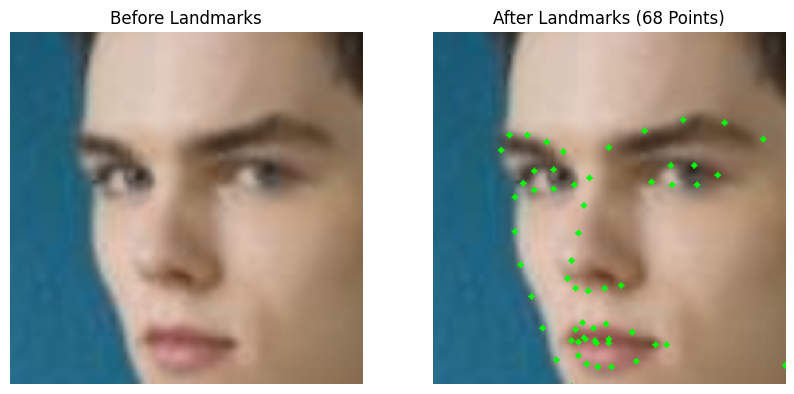

In [6]:
import cv2
import urllib.request
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. تحميل ملف الذكاء الاصطناعي (Landmarks) الخاص بـ OpenCV
model_url = "https://raw.githubusercontent.com/kurnianggoro/GSOC2017/master/data/lbfmodel.yaml"
model_path = "lbfmodel.yaml"
if not os.path.exists(model_path):
    print("جاري تحميل موديل النقاط الهندسية...")
    urllib.request.urlretrieve(model_url, model_path)

# إعداد أداة استخراج النقاط
facemark = cv2.face.createFacemarkLBF()
facemark.loadModel(model_path)

# 2. جلب الصورة التي قمنا بقصها وتوحيد حجمها سابقاً
# (تأكدي أنكِ قمتِ بتشغيل كود الـ Resizing قبل هذا الكود لتكون الصورة في الذاكرة)
img = resized_face.copy()
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# 3. إخبار الكمبيوتر بمكان الوجه (وهو الصورة بالكامل لأننا قصصناها مسبقاً)
h, w = img.shape[:2]
faces = np.array([[0, 0, w, h]])

# 4. استخراج النقاط الهندسية
ok, landmarks = facemark.fit(gray, faces)

if ok:
    print("✅ تم استخراج خريطة الوجه (Landmarks) بنجاح باستخدام OpenCV!")
    annotated_image = img.copy()

    # 5. رسم الـ 68 نقطة هندسية على الوجه (باللون الأخضر)
    for mark in landmarks[0][0]:
        x, y = int(mark[0]), int(mark[1])
        cv2.circle(annotated_image, (x, y), 2, (0, 255, 0), -1)

    # 6. عرض النتيجة النهائية
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img)
    axes[0].set_title("Before Landmarks")
    axes[0].axis('off')

    axes[1].imshow(annotated_image)
    axes[1].set_title("After Landmarks (68 Points)")
    axes[1].axis('off')

    plt.show()
else:
    print("❌ لم يتم استخراج النقاط.")